# Cycle analysis — BN vs Other

Full round-trip haul **cycles** (`load -> unload -> load`) per region, with timing &
distance, aggregated by month / week, plus a route breakdown and an interactive
truck/date explorer.

Reuses `gps_lib` (cleaning, classification, zones) and the new `gps_lib.cycles`
module. Data dir comes from `GPS_DATA_DIR` in `.env` (see README).

In [1]:
import sys
sys.path.append("../..")

import glob, os, re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from gps_lib import config, io_utils, classify, preprocess, zones, cycles

## Zones (two regions: bn vs reject+middling)

In [2]:
zone_list_df = classify.classify_zones(io_utils.load_zone_list())
zone_detail_all_df = io_utils.load_zone_detail()
zones_gdf = zones.build_zone_geodataframe(zone_detail_all_df, zone_list_df)
zones_gdf = zones_gdf[zones_gdf["zone_material_type"].isin(["bn", "reject", "middling"])].copy()
zones_gdf[["zone_id", "label", "zone_material_type", "zone_load_type"]]

,zone_id,label,zone_material_type,zone_load_type
0,25334,Reject овоолго,reject,unload
1,25384,Reject ачилтын бүс,reject,load
2,25385,Middling ачилтын бүс,middling,load
3,25559,Баруун наран ачилтын бүс /Зүүн/,bn,load
4,25685,Баруун наран овоолго,bn,unload
5,26140,SP4,middling,unload
6,27838,Баруун наран ачилтын бүс /Баруун/,bn,load
7,28368,Sp5,middling,unload
8,28420,SP7,middling,unload
9,81702,Hard sp5,middling,unload


## Build cycles for every month
Loads each `gps_data_<year>-<month>.csv`, cleans, tags zones, and extracts cycles.
Cached to `cycles_all_months.csv` in the data dir — delete it to recompute.
`DEMO_MONTH` keeps one month's tagged points for the spatial maps.

In [3]:
DEMO_MONTH = "2025-11"
tracker_list_df = classify.classify_technic_material_type(io_utils.load_tracker_list())

def cycles_for_file(path):
    tp = pd.read_csv(path, low_memory=False)
    merged = preprocess.attach_technic_info(tp, tracker_list_df)
    df = preprocess.clean_gps_points(merged, round_n=4)
    df = df[df["technic_type"] == "dump"]
    hits = cycles.assign_zone_hit_fast(df.sort_values(["tracker_id", "get_time"]), zones_gdf)
    return cycles.extract_cycles(hits), hits

CACHE = Path(config.DATA_DIR) / "cycles_all_months.csv"
month_files = sorted(
    p for p in glob.glob(str(Path(config.DATA_DIR) / "gps_data_*.csv"))
    if re.match(r"gps_data_\d{4}-\d{1,2}\.csv$", os.path.basename(p)))

# demo month tagged points (always computed, for the maps)
demo_path = str(Path(config.DATA_DIR) / f"gps_data_{DEMO_MONTH}.csv")
cycles_demo, gps_hits_demo = cycles_for_file(demo_path)

if CACHE.exists():
    all_cycles = pd.read_csv(CACHE, parse_dates=["depart_load", "arrive_unload", "depart_unload", "arrive_load"])
    all_cycles["date"] = all_cycles["depart_load"].dt.date
    print(f"loaded cache: {len(all_cycles):,} cycles")
else:
    parts = []
    for p in month_files:
        cyc = cycles_demo if p == demo_path else cycles_for_file(p)[0]
        print(f"{os.path.basename(p)}: {len(cyc)} cycles")
        parts.append(cyc)
    all_cycles = pd.concat(parts, ignore_index=True)
    io_utils.save_csv(all_cycles, "cycles_all_months.csv")
print(f"TOTAL: {len(all_cycles):,} | bn={(all_cycles.region=='bn').sum():,} other={(all_cycles.region=='other').sum():,}")

gps_data_2025-10.csv: 24603 cycles
gps_data_2025-11.csv: 13805 cycles


gps_data_2025-7.csv: 6471 cycles


gps_data_2025-8.csv: 20386 cycles


gps_data_2025-9.csv: 22061 cycles


TOTAL: 87,326 | bn=11,954 other=75,372


## Zone maps — green = load, red (hatched) = unload

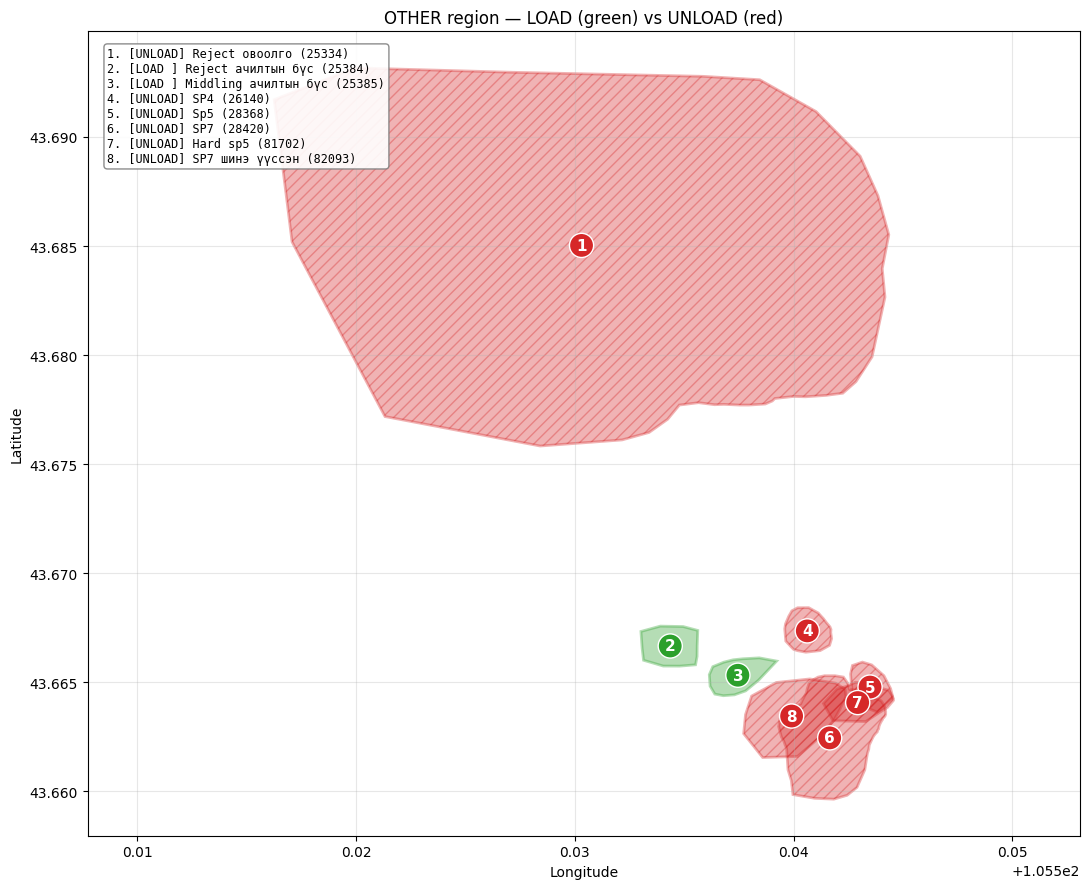

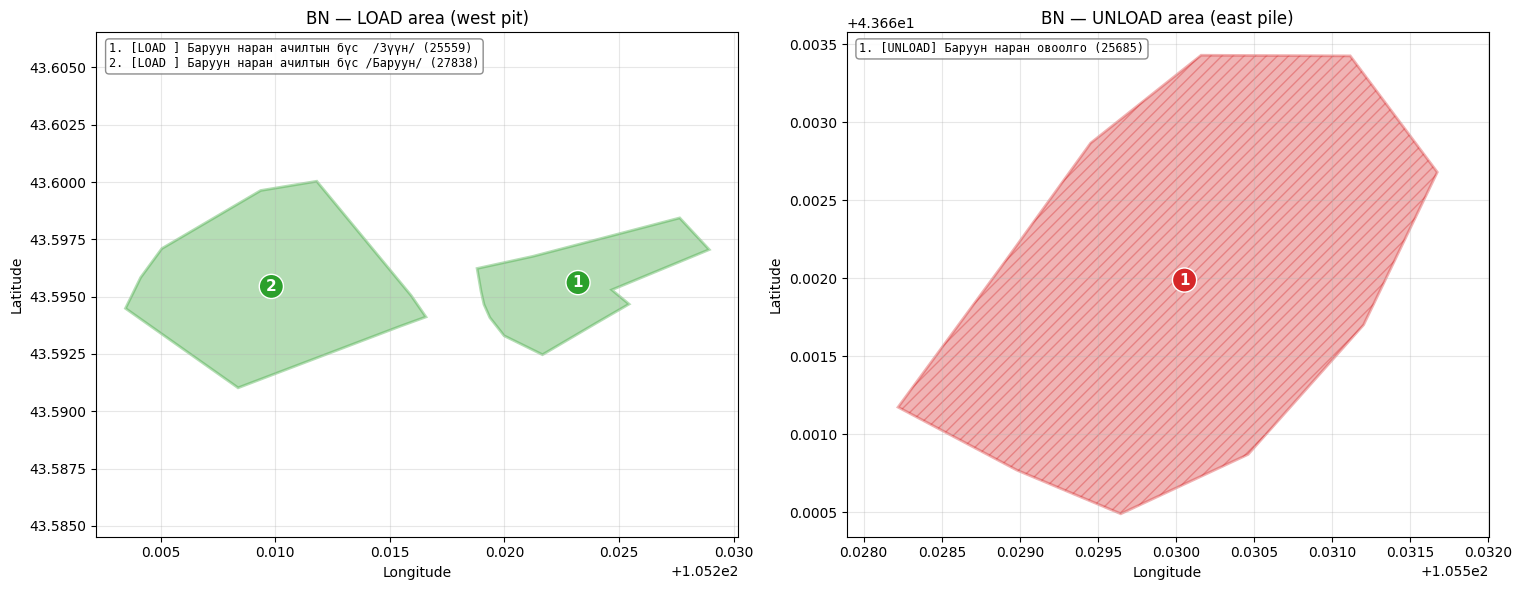

In [4]:
cycles.plot_zones_loadunload(zones_gdf, "other"); plt.show()
cycles.plot_zones_loadunload(zones_gdf, "bn"); plt.show()

## Statistics — by region / month / week

In [5]:
display(cycles.summarize_cycles(all_cycles, "region"))
display(cycles.summarize_cycles(all_cycles, ["month", "region"]))
display(cycles.summarize_cycles(all_cycles, ["week", "region"]))

,cycles,cycle_mean_min,cycle_median_min,cycle_p90_min,cycle_total_h,haul_mean_min,dump_mean_min,return_mean_min,cycle_km_mean,cycle_km_median,haul_km_mean,total_km
region,,,,,,,,,,,,
bn,11954.0,168.4,152.0,264.6,33557.9,70.5,18.3,79.6,66.55,69.57,32.86,795480.0
other,75372.0,25.6,22.4,38.3,32106.5,5.6,15.6,4.3,5.05,6.33,1.43,380749.0


cycles  cycle_mean_min  cycle_median_min  cycle_p90_min  \
month   region                                                             
2025-07 bn       1641.0           157.9             141.7          256.8   
        other    4830.0            23.0               8.3           58.8   
2025-08 bn       2625.0           163.7             145.6          265.2   
        other   17761.0            24.7              20.2           36.2   
2025-09 bn       2398.0           166.8             147.8          261.6   
        other   19663.0            24.6              23.1           36.0   
2025-10 bn       2853.0           169.0             152.9          259.8   
        other   21750.0            27.2              25.1           39.4   
2025-11 bn       2437.0           181.6             164.9          274.1   
        other   11368.0            26.4              22.4           40.7   

                cycle_total_h  haul_mean_min  dump_mean_min  return_mean_min  \
month   region                                                                 
2025-07 bn             4319.9           68.1           16.7             73.2   
        other          1855.1            2.4           18.4              2.2   
2025-08 bn             7160.3           68.5           20.2             75.0   
        other          7321.8            5.6           14.7              4.5   
2025-09 bn             6666.9           71.3           15.5             80.0   
        other          8054.1            5.7           14.8              4.2   
2025-10 bn             8036.0           69.7           18.7             80.6   
        other          9873.2            6.4           15.9              5.0   
2025-11 bn             7374.9           74.6           19.4             87.5   
        other          5002.3            5.4           16.9              4.1   

                cycle_km_mean  cycle_km_median  haul_km_mean  total_km  
month   region                                                          
2025-07 bn              62.20            69.32         31.65  102074.0  
        other            2.38             1.39          0.37   11495.0  
2025-08 bn              63.26            69.47         31.66  166064.0  
        other            4.88             6.22          1.54   86666.0  
2025-09 bn              67.93            69.61         33.41  162885.0  
        other            5.12             6.58          1.42  100671.0  
2025-10 bn              67.88            69.64         33.03  193661.0  
        other            5.83             7.11          1.61  126824.0  
2025-11 bn              70.08            69.71         34.21  170795.0  
        other            4.85             6.36          1.37   55094.0

cycles  cycle_mean_min  cycle_median_min  \
week                  region                                             
2025-06-30/2025-07-06 bn       308.0           158.8             142.8   
                      other    698.0            26.6               8.3   
2025-07-07/2025-07-13 bn       380.0           167.9             152.9   
                      other   1450.0            19.2               8.5   
2025-07-14/2025-07-20 bn       256.0           146.0             134.2   
                      other    714.0            34.2               9.2   
2025-07-21/2025-07-27 bn       456.0           151.4             134.2   
                      other   1621.0            18.2               7.9   
2025-07-28/2025-08-03 bn       548.0           173.0             158.2   
                      other   2573.0            27.4              23.7   
2025-08-04/2025-08-10 bn       484.0           160.0             141.9   
                      other   2993.0            31.2              22.6   
2025-08-11/2025-08-17 bn       645.0           159.5             142.8   
                      other   4651.0            21.2              18.4   
2025-08-18/2025-08-24 bn       625.0           163.4             150.7   
                      other   4555.0            21.1              19.0   
2025-08-25/2025-08-31 bn       564.0           164.0             139.4   
                      other   3336.0            27.4              22.4   
2025-09-01/2025-09-07 bn       517.0           159.3             140.8   
                      other   4300.0            25.7              22.0   
2025-09-08/2025-09-14 bn       612.0           161.6             137.1   
                      other   4337.0            21.5              19.9   
2025-09-15/2025-09-21 bn       430.0           171.4             148.2   
                      other   4643.0            23.8              23.5   
2025-09-22/2025-09-28 bn       638.0           175.4             160.3   
                      other   5033.0            25.3              25.1   
2025-09-29/2025-10-05 bn       733.0           164.7             148.2   
                      other   5415.0            27.7              24.3   
2025-10-06/2025-10-12 bn       702.0           168.4             150.6   
                      other   5719.0            26.7              25.4   
2025-10-13/2025-10-19 bn       528.0           172.3             157.9   
                      other   3593.0            29.3              27.1   
2025-10-20/2025-10-26 bn       622.0           166.9             152.4   
                      other   4456.0            27.5              25.2   
2025-10-27/2025-11-02 bn       652.0           173.6             156.0   
                      other   4964.0            26.0              22.5   
2025-11-03/2025-11-09 bn       660.0           179.3             163.3   
                      other   2757.0            28.5              22.2   
2025-11-10/2025-11-16 bn       414.0           191.9             176.0   
                      other   1541.0            26.0              21.0   
2025-11-17/2025-11-23 bn       507.0           183.5             168.0   
                      other   2008.0            29.7              23.7   
2025-11-24/2025-11-30 bn       673.0           178.5             160.5   
                      other   4015.0            23.8              21.8   

                              cycle_p90_min  cycle_total_h  haul_mean_min  \
week                  region                                                
2025-06-30/2025-07-06 bn              253.0          815.0           67.7   
                      other            69.9          309.2            2.8   
2025-07-07/2025-07-13 bn              268.3         1063.5           72.3   
                      other            32.5          463.1            1.9   
2025-07-14/2025-07-20 bn              225.7          622.8           64.3   
                      other            88.4          407.2            2.8   
2025-07-2

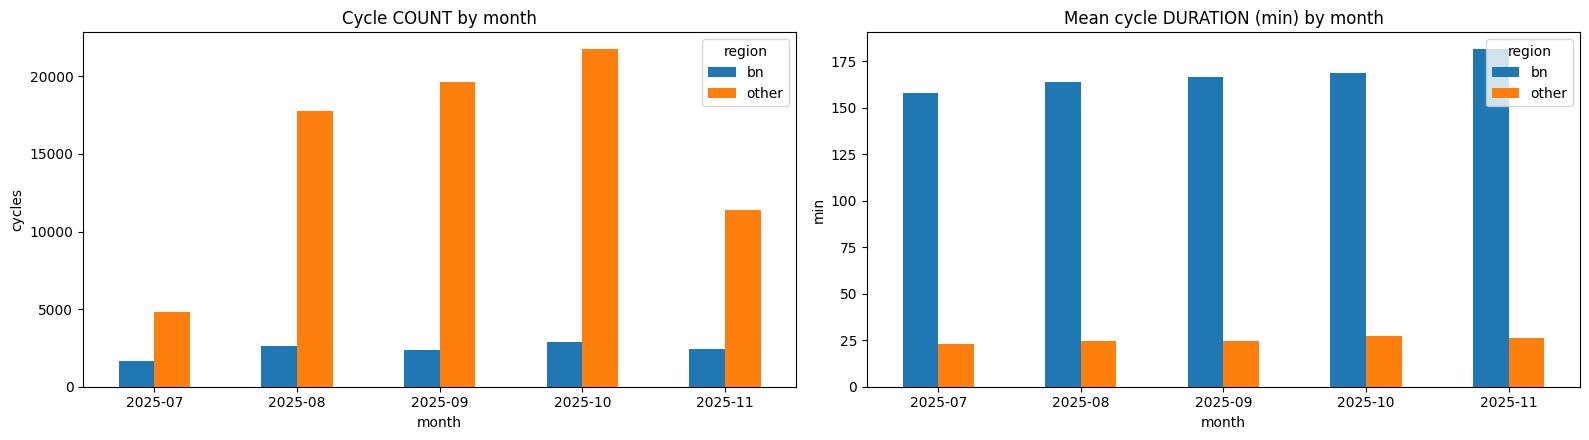

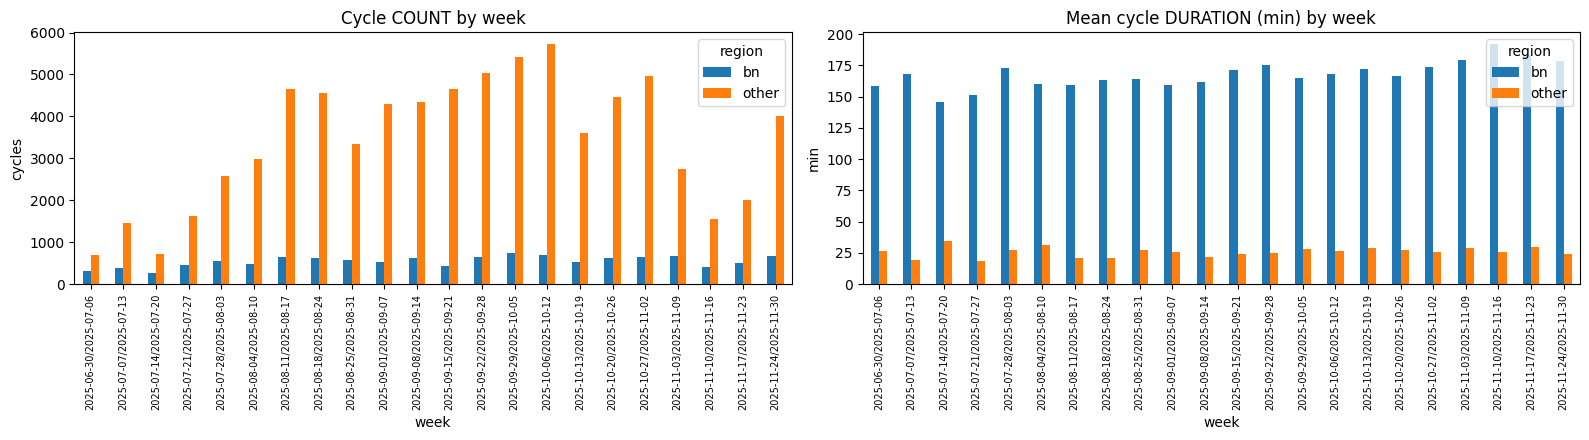

In [6]:
cycles.plot_cycles_by_period(all_cycles, "month"); plt.show()
cycles.plot_cycles_by_period(all_cycles, "week"); plt.show()

## One truck — route + timeline (demo month)

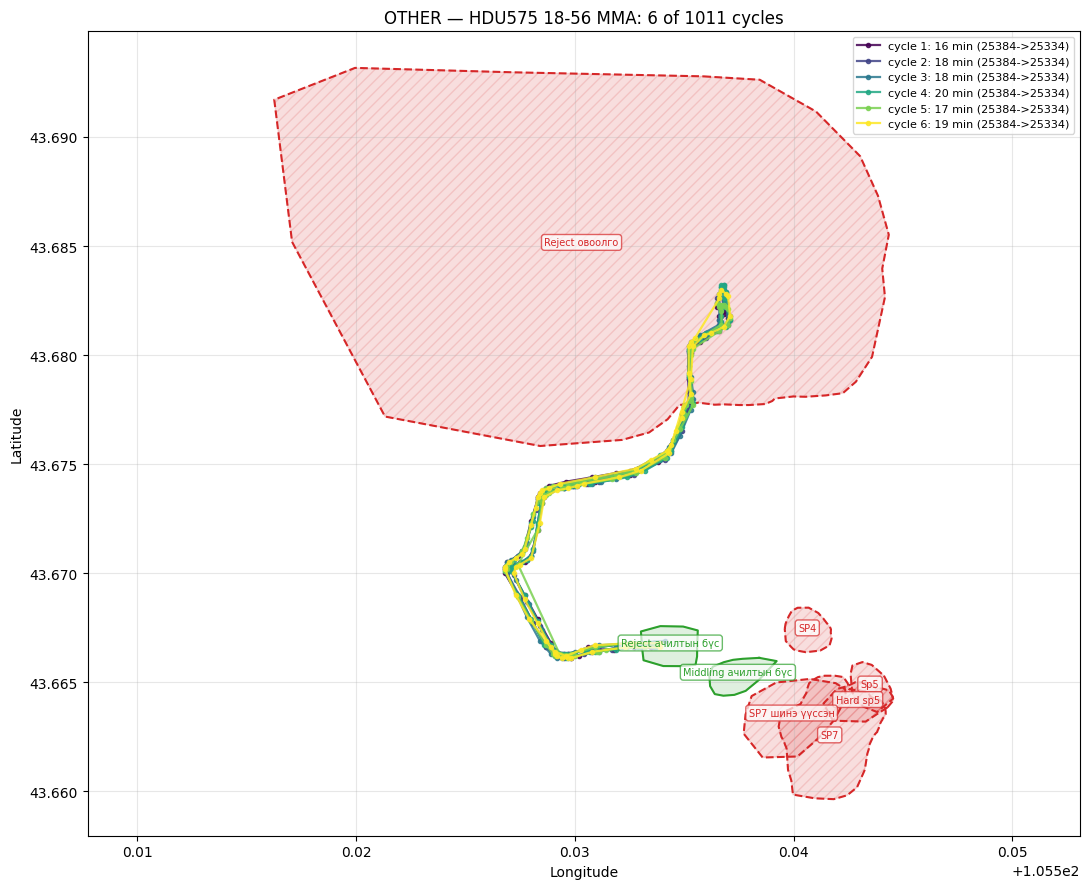

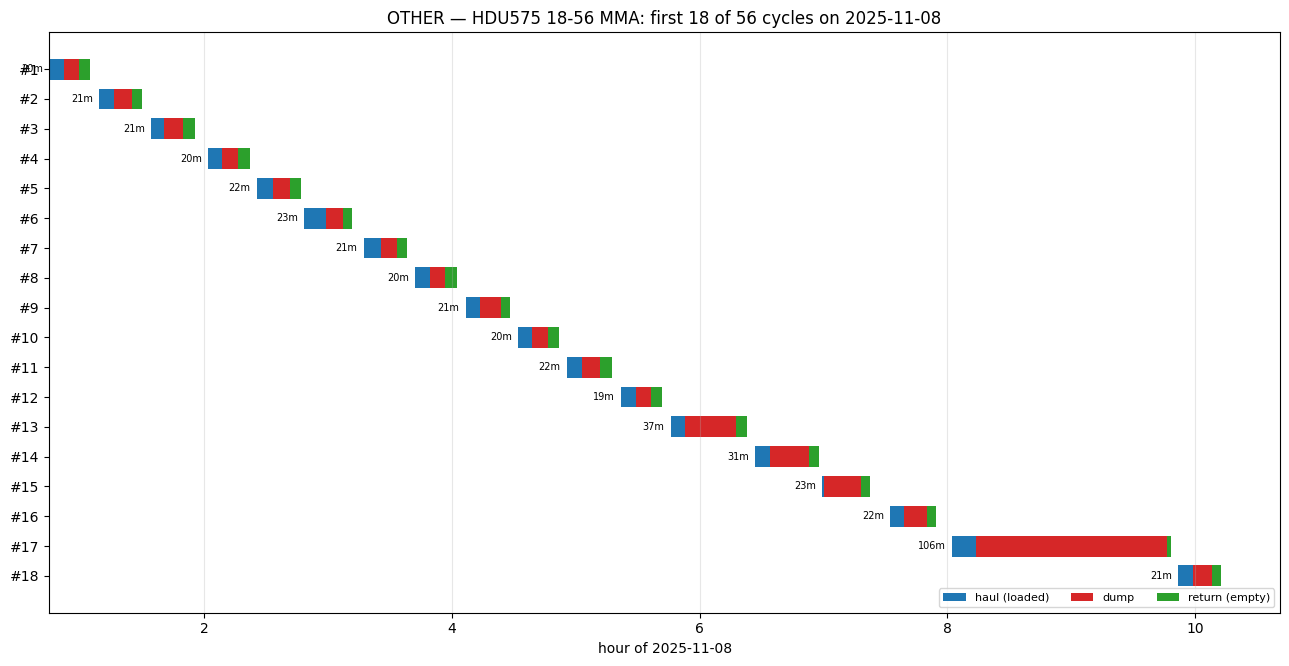

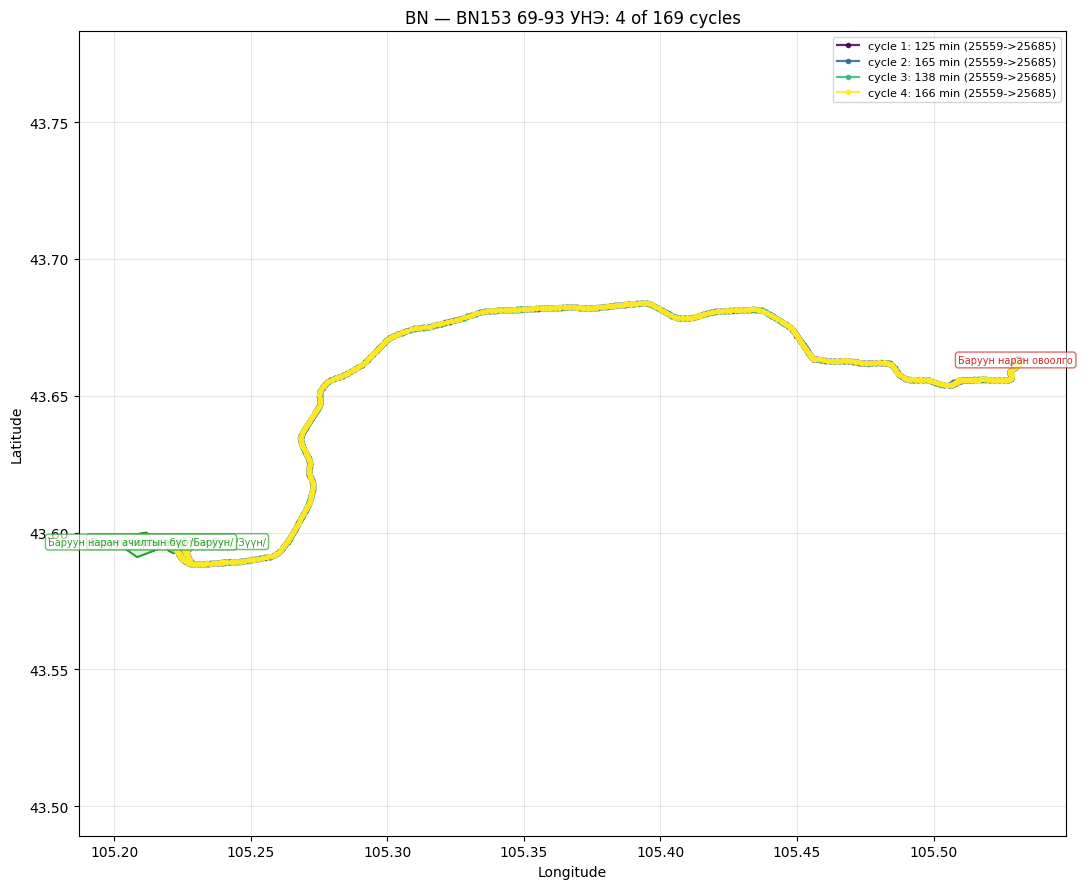

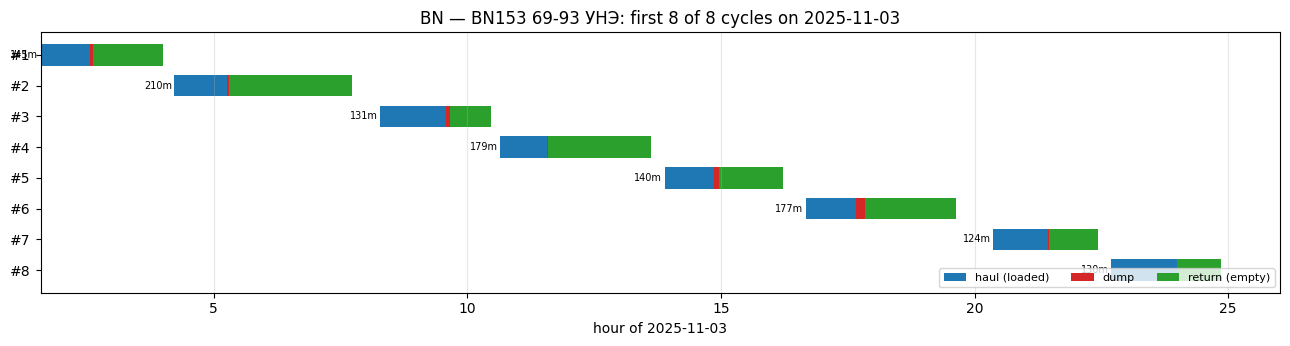

In [7]:
_, tid_o = cycles.plot_truck_cycles(cycles_demo, gps_hits_demo, zones_gdf, "other"); plt.show()
cycles.plot_truck_timeline(cycles_demo, "other", tid_o); plt.show()
_, tid_b = cycles.plot_truck_cycles(cycles_demo, gps_hits_demo, zones_gdf, "bn", max_cycles=4); plt.show()
cycles.plot_truck_timeline(cycles_demo, "bn", tid_b); plt.show()

## Routes within each region (load -> unload pairs)

=== OTHER — 75,372 cycles ===


,load,unload,load_mat,unload_mat,cycles,share_pct,haul_km,cycle_km,straight_km,haul_min,cycle_min
0,Reject ачилтын бүс,Reject овоолго,reject,reject,45812,60.8,2.17,7.19,2.07,7.9,26.5
11,Middling ачилтын бүс,SP7 шинэ үүссэн,middling,middling,17369,23.0,0.21,1.31,0.29,1.8,13.7
8,Middling ачилтын бүс,SP4,middling,middling,8583,11.4,0.23,1.98,0.34,1.2,41.7
10,Middling ачилтын бүс,SP7,middling,middling,2609,3.5,0.59,1.99,0.46,3.8,19.8
5,Reject ачилтын бүс,SP7 шинэ үүссэн,reject,middling,494,0.7,0.93,6.27,0.57,9.0,83.7
9,Middling ачилтын бүс,Sp5,middling,middling,314,0.4,0.70,1.73,0.49,5.7,26.5


=== BN — 11,954 cycles ===


,load,unload,load_mat,unload_mat,cycles,share_pct,haul_km,cycle_km,straight_km,haul_min,cycle_min
9,Баруун наран ачилтын бүс /Зүүн/,Баруун наран овоолго,bn,bn,11353,95.0,34.40,69.27,25.78,73.6,170.6
5,Middling ачилтын бүс,SP4,middling,middling,448,3.7,0.18,8.48,0.34,1.1,117.1
8,Middling ачилтын бүс,SP7 шинэ үүссэн,middling,middling,49,0.4,1.06,6.79,0.29,8.7,68.4
11,Баруун наран ачилтын бүс /Зүүн/,SP7,bn,middling,47,0.4,39.00,76.05,26.69,98.4,260.2


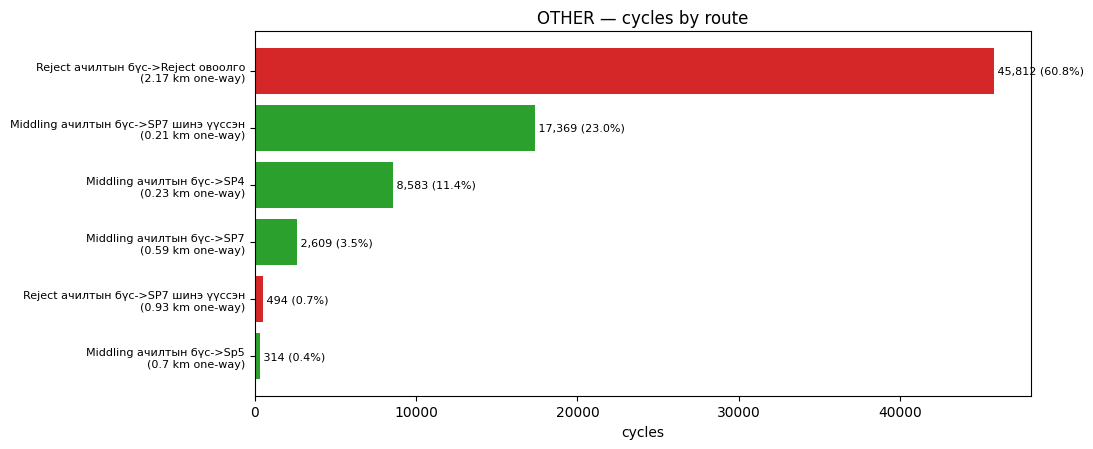

In [8]:
for region in ["other", "bn"]:
    full, main = cycles.route_breakdown(all_cycles, zones_gdf, region)
    print(f"=== {region.upper()} — {int(full.cycles.sum()):,} cycles ===")
    display(main[["load", "unload", "load_mat", "unload_mat", "cycles", "share_pct",
                  "haul_km", "cycle_km", "straight_km", "haul_min", "cycle_min"]])
_, main_other = cycles.route_breakdown(all_cycles, zones_gdf, "other")
cycles.plot_route_breakdown(main_other, "other"); plt.show()

## Interactive explorer — pick a truck & date
Needs a live kernel. Trucks/dates span all months; first pick in a new month loads it once.

In [9]:
import ipywidgets as widgets
from IPython.display import display, clear_output

_TAGGED = {DEMO_MONTH: gps_hits_demo}
def _month_token(d): return f"{d.year}-{d.month}"
def _get_tagged(tok):
    if tok not in _TAGGED:
        print(f"  loading {tok} ...")
        _TAGGED[tok] = cycles_for_file(str(Path(config.DATA_DIR) / f"gps_data_{tok}.csv"))[1]
    return _TAGGED[tok]

def _truck_opts(region):
    s = (all_cycles[all_cycles.region == region].groupby("tracker_id")
         .agg(truck=("truck", "first"), n=("cycle_s", "size")).sort_values("n", ascending=False))
    return [(f"{r.truck.strip()} — {r.n} cycles", tid) for tid, r in s.iterrows()]

w_region = widgets.Dropdown(options=["other", "bn"], value="other", description="Region:")
w_truck = widgets.Dropdown(description="Truck:")
w_date = widgets.Dropdown(description="Date:")
w_out = widgets.Output()

def _on_region(*_): w_truck.options = _truck_opts(w_region.value)
def _on_truck(*_):
    if w_truck.value is None: return
    days = sorted(all_cycles[(all_cycles.region == w_region.value) & (all_cycles.tracker_id == w_truck.value)]["date"].unique())
    w_date.options = [str(d) for d in days]
    demo = [str(d) for d in days if _month_token(d) == DEMO_MONTH]
    w_date.value = demo[0] if demo else (str(days[0]) if days else None)
def _on_date(*_):
    with w_out:
        clear_output(wait=True)
        if w_truck.value is None or w_date.value is None: return
        day = pd.to_datetime(w_date.value).date()
        fig = cycles.plot_truck_day(all_cycles, _get_tagged(_month_token(day)), zones_gdf,
                                    w_region.value, w_truck.value, day)
        if fig is not None: plt.show()

w_region.observe(_on_region, "value"); w_truck.observe(_on_truck, "value"); w_date.observe(_on_date, "value")
_on_region()
display(widgets.VBox([widgets.HBox([w_region, w_truck, w_date]), w_out]))

## Export

In [10]:
def _ds(g): return cycles.cycle_stats(g)
import time
def _safe(fn, what):
    for _ in range(3):
        try: fn(); print("saved", what); return
        except Exception as e: print("retry", what, e); time.sleep(2)
def _xlsx():
    with pd.ExcelWriter(Path(config.DATA_DIR) / "cycle_report_all_months.xlsx") as xl:
        all_cycles.sort_values(["region", "tracker_id", "depart_load"]).to_excel(xl, "all_cycles", index=False)
        cycles.summarize_cycles(all_cycles, "region").to_excel(xl, "by_region")
        cycles.summarize_cycles(all_cycles, ["month", "region"]).to_excel(xl, "by_month")
        cycles.summarize_cycles(all_cycles, ["week", "region"]).to_excel(xl, "by_week")
_safe(_xlsx, "cycle_report_all_months.xlsx")

/var/folders/ks/mdjr3g896kq1czm64bx8s6y40000gn/T/ipykernel_91936/329098554.py:9: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  all_cycles.sort_values(["region", "tracker_id", "depart_load"]).to_excel(xl, "all_cycles", index=False)


/var/folders/ks/mdjr3g896kq1czm64bx8s6y40000gn/T/ipykernel_91936/329098554.py:10: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  cycles.summarize_cycles(all_cycles, "region").to_excel(xl, "by_region")
/var/folders/ks/mdjr3g896kq1czm64bx8s6y40000gn/T/ipykernel_91936/329098554.py:11: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  cycles.summarize_cycles(all_cycles, ["month", "region"]).to_excel(xl, "by_month")
/var/folders/ks/mdjr3g896kq1czm64bx8s6y40000gn/T/ipykernel_91936/329098554.py:12: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  cycles.summarize_cycles(all_cycles, ["week", "region"]).to_excel(xl, "by_week")


saved cycle_report_all_months.xlsx
